In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')



In [3]:
df=pd.read_csv('Data/stud.csv')



In [4]:
df.head()



,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
df.isnull().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [6]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 103.5 KB


In [7]:
## Check Duplicates
df.duplicated().sum()


np.int64(0)

In [8]:
df['gender'].unique()


<ArrowStringArray>
['female', 'male']
Length: 2, dtype: str

In [9]:
df['race_ethnicity'].value_counts()


race_ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

In [10]:
df['parental_level_of_education'].value_counts()


parental_level_of_education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

In [11]:
df['lunch'].value_counts()



lunch
standard        645
free/reduced    355
Name: count, dtype: int64

In [12]:
df['test_preparation_course'].value_counts()


test_preparation_course
none         642
completed    358
Name: count, dtype: int64

In [13]:
df.describe()



,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [14]:
cat_features=df.select_dtypes(include=['str','object']).columns
num_features=df.select_dtypes(exclude=['str','object']).columns

print(f"The no. of categorical  features are {len(cat_features)}")
print(f"The no. of numerical  features are {len(num_features)}")


The no. of categorical  features are 5
The no. of numerical  features are 3


## Adding columns for total score and average

In [15]:
df.head(2)



,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88


In [16]:
df['total_score']=df['math_score']+df['reading_score']+df['writing_score']
df['average_score']=df['total_score']/3
df.head()


,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [17]:
reading_full=df[df['reading_score']==100]['average_score'].count()
writing_full=df[df['writing_score']==100]['average_score'].count()
maths_full=df[df['math_score']==100]['average_score'].count()

print(f"Number of students who got full marks in reading : {reading_full}")
print(f"Number of students who got full marks in maths : {maths_full}")
print(f"Number of students who got full marks in writing : {writing_full}")



Number of students who got full marks in reading : 17
Number of students who got full marks in maths : 7
Number of students who got full marks in writing : 14


In [18]:
reading_less_than_20=df[df['reading_score']<=20]['average_score'].count()
writing_less_than_20=df[df['writing_score']<=20]['average_score'].count()
maths_less_than_20=df[df['math_score']<=20]['average_score'].count()


print(f"The Number of students who got marks less than 20 in reading are {reading_less_than_20}")
print(f"The no. of students who got marks less than 20 in maths are {maths_less_than_20}")
print(f"The no. of students who got marks less than 20 in writing are {writing_less_than_20}")


The Number of students who got marks less than 20 in reading are 1
The no. of students who got marks less than 20 in maths are 4
The no. of students who got marks less than 20 in writing are 3


### Data Visualization

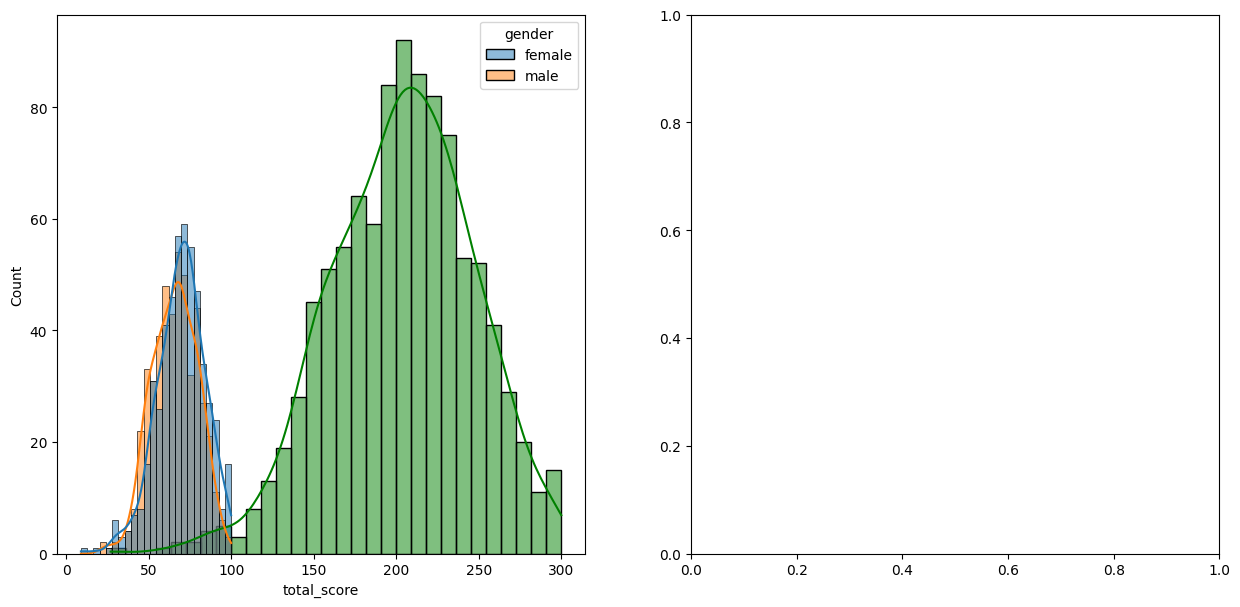

In [19]:
fig, axs=plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df,x='total_score',bins=30,kde=True,color='g')
plt.subplot(121)
sns.histplot(data=df,x='average_score',kde=True,hue='gender')
plt.show()



In [20]:
df.to_csv('newer_data.csv',index=False)

